"""
Train ALL Base Agents: Sentiment + Technical with PPO and SAC

This is your main training script. Run this to train all 4 base agents:
- Sentiment PPO
- Sentiment SAC
- Technical PPO
- Technical SAC

Then see which algorithms win for each agent type.
"""

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC, PPO
from sentiment_enviroment import SentimentEnv
from technical_enviroment import TechnicalEnv
from agent_wrapper import *
import warnings
from custom_function import add_regime_indicator



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
warnings.filterwarnings("ignore")


## Configuration

All parameters in one place for easy experimentation


In [7]:
# Environment Reward Parameters

# Base Agents (Sentiment & Technical)
# Reward: Sharpe-like ratio (mean_return / volatility)
sentiment_env_config = {
    'vol_window': 3,           # Rolling window for Sharpe-like reward calculation
    'transaction_cost': 0.002, # 0.1% transaction cost per rebalance
    'risk_lambda': 0.5,        # Risk penalty weight (for reference)
}

technical_env_config = {
    'vol_window': 3,           # Rolling window for Sharpe-like reward calculation
}

# Hierarchical Agents (Super & Meta)
# Reward: alpha1*log_returns - alpha2*mdd - alpha3*vol + exploration_bias
super_agent_config = {
    'alpha1': 5.0,             # Weight for log returns
    'alpha2': 0.5,             # Weight for max drawdown penalty
    'alpha3': 0.5,             # Weight for volatility penalty
    'exploration_bias': 0.01,  # Small positive constant for exploration
}

meta_agent_config = {
    'alpha1': 5.0,             # Weight for log returns
    'alpha2': 0.5,             # Weight for max drawdown penalty
    'alpha3': 0.5,             # Weight for volatility penalty
    'exploration_bias': 0.01, # Small positive constant for exploration
}

# Regime Indicators (for Super & Meta agents)
regime_config = {
    'enabled': True,           # Enable/disable regime indicators
    'window': 6,               # SMA window for regime detection (months)
}

# RL Algorithm Hyperparameters

# PPO Configuration
ppo_config = {
    'learning_rate': 3e-4,     # Learning rate
    'n_steps': 2048,           # Steps per update
    'batch_size': 64,          # Batch size
    'n_epochs': 15,            # Epochs per update
    'ent_coef': 0.02,          # Entropy coefficient (exploration)
}

# SAC Configuration
sac_config = {
    'learning_rate': 3e-4,     # Learning rate
    'buffer_size': 20000,      # Replay buffer size
    'learning_starts': 100,    # Steps before learning starts
    'batch_size': 128,         # Batch size
    'ent_coef': 'auto',        # Entropy coefficient (auto-tuned)
}

# Training Configuration
training_config = {
    'train_ratio': 0.60,       # 60% for training
    'val_ratio': 0.20,         # 20% for validation
    'timesteps': 200000,       # Total training timesteps
    'algorithm': 'both',       # 'ppo', 'sac', or 'both'
}

print("Configuration loaded:")
print(f"\nBase Agents:")
print(f"  Sentiment vol_window: {sentiment_env_config['vol_window']}")
print(f"  Technical vol_window: {technical_env_config['vol_window']}")
print(f"\nHierarchical Agents:")
print(f"  Super alpha1={super_agent_config['alpha1']}, alpha2={super_agent_config['alpha2']}, alpha3={super_agent_config['alpha3']}")
print(f"  Meta alpha1={meta_agent_config['alpha1']}, alpha2={meta_agent_config['alpha2']}, alpha3={meta_agent_config['alpha3']}")
print(f"  Regime indicators: {'Enabled' if regime_config['enabled'] else 'Disabled'} (window={regime_config['window']} months)")
print(f"\nRL Algorithms:")
print(f"  PPO ent_coef: {ppo_config['ent_coef']}")
print(f"  SAC ent_coef: {sac_config['ent_coef']}")
print(f"\nTraining:")
print(f"  Timesteps: {training_config['timesteps']:,}")
print(f"  Algorithm: {training_config['algorithm']}")


Configuration loaded:

Base Agents:
  Sentiment vol_window: 3
  Technical vol_window: 3

Hierarchical Agents:
  Super alpha1=5.0, alpha2=0.5, alpha3=0.5
  Meta alpha1=5.0, alpha2=0.5, alpha3=0.5
  Regime indicators: Enabled (window=6 months)

RL Algorithms:
  PPO ent_coef: 0.02
  SAC ent_coef: auto

Training:
  Timesteps: 200,000
  Algorithm: both


In [4]:
price_data = pd.read_csv("data/monthly_prices.csv", index_col=0, parse_dates=True)
technical_features = pd.read_csv("data/technical_indicators.csv", index_col=0, parse_dates=True)
sentiment_features = pd.read_csv("data/nlp_features.csv", index_col=0, parse_dates=True)
common_dates = technical_features.index.intersection(sentiment_features.index)
price_data = price_data.loc[common_dates]
technical_features = technical_features.loc[common_dates]
sentiment_features = sentiment_features.loc[common_dates]
# Check data quality
print(f"Total months: {len(price_data)}")
print(f"NaN in prices: {price_data.isnull().sum().sum()}")
print(f"Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}")

Total months: 129
NaN in prices: 0
Date range: 2015-02-28 to 2025-10-31


## Add Market Regime Indicators

These indicators help super and meta agents adapt to bull/bear market conditions


In [8]:

# Add regime indicators for super and meta agents
# 1=bull market (price > SMA), 0=bear market (price < SMA)
if regime_config['enabled']:
    regime_indicators = add_regime_indicator(price_data, window=regime_config['window'])
    
    print(f"Regime indicators shape: {regime_indicators.shape}")
    #print(f"Regime indicators columns: {regime_indicators.columns.tolist()}")
    print(f"\nRecent market regimes:")
    #print(regime_indicators.tail(3))
    
    # Summary statistics
    bull_pct = (regime_indicators == 1).sum().sum() / regime_indicators.size * 100
    print(f"\nBull market periods: {bull_pct:.1f}%")
    print(f"Bear market periods: {100-bull_pct:.1f}%")
else:
    regime_indicators = None
    print("Regime indicators disabled")


Regime indicators shape: (129, 10)

Recent market regimes:

Bull market periods: 60.7%
Bear market periods: 39.3%


In [9]:
results, summary = train_and_evaluate_with_split(
    price_data,
    technical_features,
    sentiment_features,
    train_ratio=training_config['train_ratio'],
    val_ratio=training_config['val_ratio'],
    timesteps=training_config['timesteps'],
    algorithm=training_config['algorithm'],
    sentiment_env_params=sentiment_env_config,
    technical_env_params=technical_env_config,
    ppo_params=ppo_config,
    sac_params=sac_config
)



DATA SPLITTING

Total data: 129 months
Date range: 2015-02-28 00:00:00 to 2025-10-31 00:00:00

DATA SPLIT SUMMARY:
✓ Train:  77 months (60%) | 2015-02 to 2021-06
✓ Val:    25 months (20%) | 2021-07 to 2023-07
✓ Test:   27 months (20%) | 2023-08 to 2025-10

✓ No data leakage - splits are properly separated

TRAINING SENTIMENT AGENTS

[Sentiment PPO]
Sentiment Environment initialized:
  - Assets: 10
  - Sentiment features: 53
  - Time steps: 77
  - Date range: 2015-02-28 00:00:00 to 2021-06-30 00:00:00
Sentiment Environment initialized:
  - Assets: 10
  - Sentiment features: 53
  - Time steps: 25
  - Date range: 2021-07-31 00:00:00 to 2023-07-31 00:00:00

Training Sentiment with PPO...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 76       |
|    ep_rew_mean     | 55.6     |
| time/              |          |
|    fps             | 4167     |
|    ite


CREATING VISUALIZATIONS
✓ Plot saved: ./models/train_val_test_comparison.png


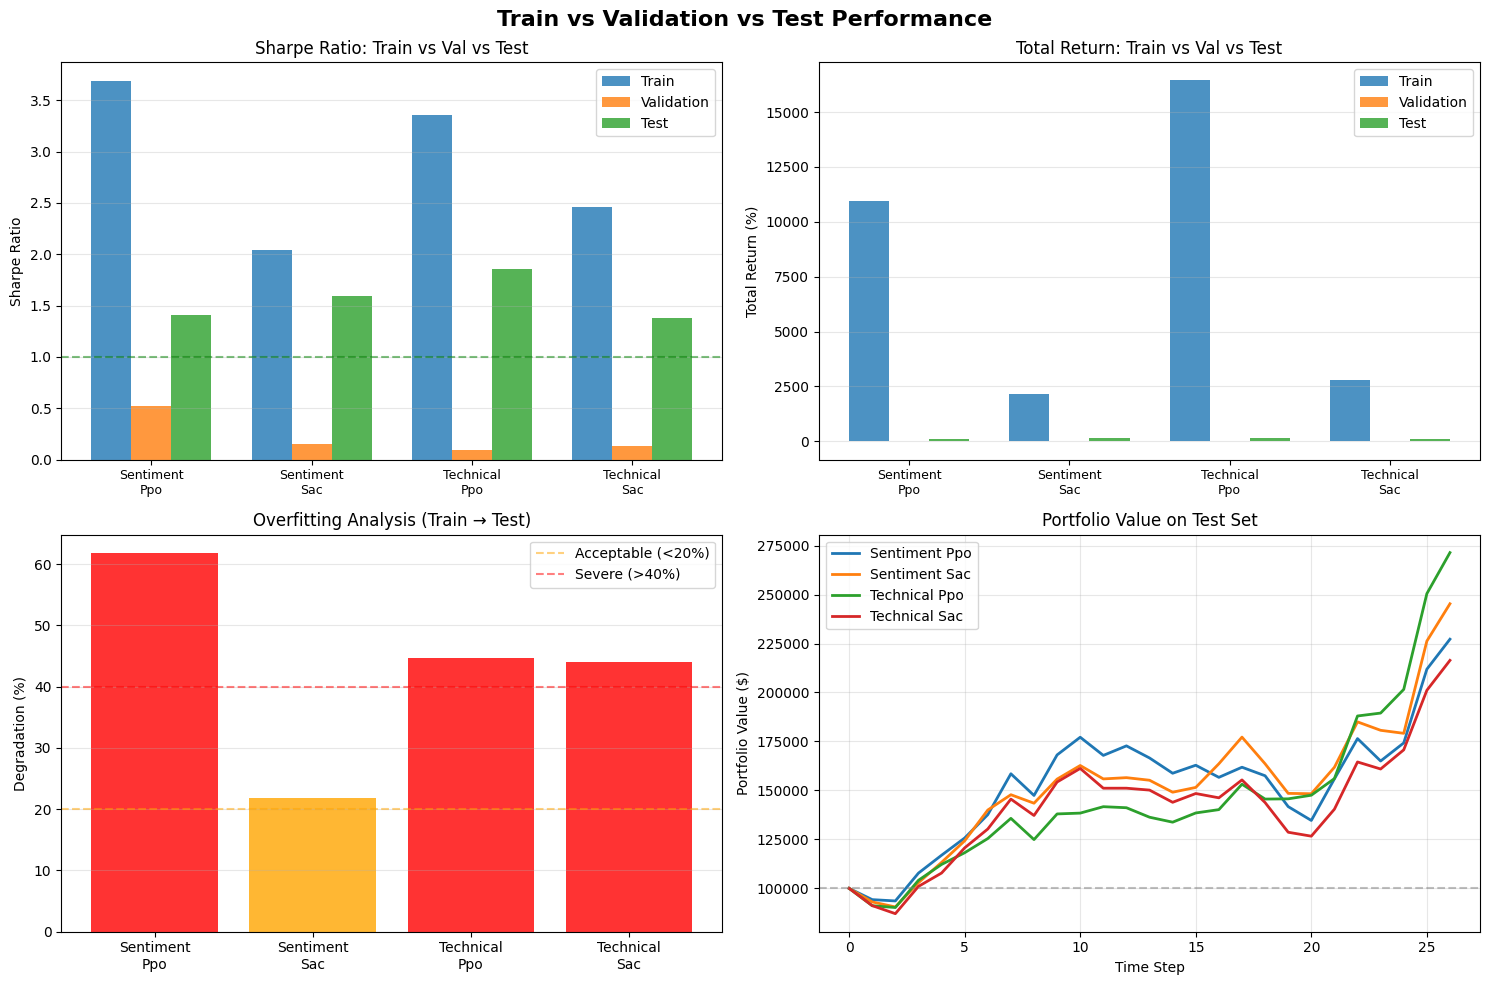

In [12]:
# VISUALIZE

print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

fig = plot_train_val_test_comparison(results)

import os
os.makedirs('./models', exist_ok=True)
fig.savefig('./models/train_val_test_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: ./models/train_val_test_comparison.png")


In [13]:
# SAVE BEST MODELS
print("SAVING MODELS")


# Save all models
for name, res in results.items():
    res['model'].save(f'./models/{name}_final')
    print(f"✓ Saved: ./models/{name}_final.zip")

print("✅ TRAINING COMPLETE!")

# Find best model based on test performance
best_agent = max(results.items(), 
                key=lambda x: x[1]['test_metrics']['sharpe_ratio'])
best_name = best_agent[0].replace('_', ' ').title()
best_sharpe = best_agent[1]['test_metrics']['sharpe_ratio']

print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   Test Sharpe: {best_sharpe:.3f}")
print(f"\n📊 KEY TAKEAWAYS:")
print(f"   - Always split data chronologically")
print(f"   - Train on past, test on future")
print(f"   - Watch for overfitting (train >> test)")
print(f"   - Use validation set to tune hyperparameters")
print(f"   - Test set is sacred (evaluate only once!)")
print("="*70)

plt.show()

SAVING MODELS
✓ Saved: ./models/sentiment_ppo_final.zip
✓ Saved: ./models/sentiment_sac_final.zip
✓ Saved: ./models/technical_ppo_final.zip
✓ Saved: ./models/technical_sac_final.zip
✅ TRAINING COMPLETE!

🏆 BEST MODEL: Technical Ppo
   Test Sharpe: 1.857

📊 KEY TAKEAWAYS:
   - Always split data chronologically
   - Train on past, test on future
   - Watch for overfitting (train >> test)
   - Use validation set to tune hyperparameters
   - Test set is sacred (evaluate only once!)


In [ ]:


class HierarchicalTrainingPipeline:
    def __init__(self, price_data, technical_features, sentiment_features):
        self.price_data = price_data
        self.technical_features = technical_features
        self.sentiment_features = sentiment_features
        
        # Agent placeholders
        self.sentiment_agent = None
        self.technical_agent = None
        self.super_agent = None
        self.meta_agent = None
    
    def train_base_agents(self, timesteps_per_agent=100000):
        """
        Step 1: Train sentiment and technical agents independently
        """
        print("=" * 60)
        print("STEP 1: Training Base Agents")
        print("=" * 60)
        
        # Train sentiment agent
        print("\n[1/2] Training Sentiment Agent...")
        sentiment_env = SentimentEnv(self.price_data, self.sentiment_features)
        sentiment_model = PPO(
            "MlpPolicy",
            sentiment_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64
        )
        sentiment_model.learn(total_timesteps=timesteps_per_agent)
        
        # Create agent wrapper with weights attribute
        self.sentiment_agent = AgentWrapper(sentiment_model, sentiment_env)
        
        metrics = sentiment_env.get_portfolio_metrics()
        print(f"Sentiment Agent - Sharpe: {metrics['sharpe_ratio']:.3f}, "
              f"Return: {metrics['total_return']:.2%}")
        
        # Train technical agent
        print("\n[2/2] Training Technical Agent...")
        technical_env = TechnicalEnv(self.price_data, self.technical_features)
        technical_model = PPO(
            "MlpPolicy",
            technical_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64
        )
        technical_model.learn(total_timesteps=timesteps_per_agent)
        
        # Create agent wrapper with weights attribute
        self.technical_agent = AgentWrapper(technical_model, technical_env)
        
        metrics = technical_env.get_portfolio_metrics()
        print(f"Technical Agent - Sharpe: {metrics['sharpe_ratio']:.3f}, "
              f"Return: {metrics['total_return']:.2%}")
        
        return self.sentiment_agent, self.technical_agent


class AgentWrapper:
    """
    Wrapper to add weights attribute and env reference to trained agents.
    This is needed for hierarchical coordination.
    """
    def __init__(self, model, env):
        self.model = model
        self.env = env
        n_assets = len(env.unwrapped.price_data.columns) if hasattr(env, 'unwrapped') else len(env.price_data.columns)
        self.weights = np.ones(n_assets) / n_assets
    
    def predict(self, obs, deterministic=True):
        action, state = self.model.predict(obs, deterministic=deterministic)
        # Update weights when predicting
        action = np.clip(action, 0, 1)
        total = action.sum()
        if total > 1e-6:
            self.weights = action / total
        return action, state
    
    def reset(self, seed=None):
        return self.env.reset(seed=seed)
    
    def learn(self, *args, **kwargs):
        return self.model.learn(*args, **kwargs)
    
    def save(self, path):
        self.model.save(path)
    
    def load(self, path):
        self.model = self.model.load(path, env=self.env)
    
    def train_super_agent(self, timesteps=100000):
        """
        Step 2: Train super agent to combine base agents
        (Base agents are frozen - we use their trained policies)
        """
        print("\n" + "=" * 60)
        print("STEP 2: Training Super Agent")
        print("=" * 60)
        
        if self.sentiment_agent is None or self.technical_agent is None:
            raise ValueError("Base agents must be trained first!")
        
        print("\n[1/1] Training Super Agent to combine base agents...")
        super_env = SuperAgentEnv(
            self.price_data,
            self.sentiment_agent,
            self.technical_agent
        )
        
        super_model = PPO(
            "MlpPolicy",
            super_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64
        )
        super_model.learn(total_timesteps=timesteps)
        
        # Create agent wrapper
        self.super_agent = AgentWrapper(super_model, super_env)
        
        metrics = super_env.get_portfolio_metrics()
        print(f"Super Agent - Sharpe: {metrics['sharpe_ratio']:.3f}, "
              f"Return: {metrics['total_return']:.2%}")
        
        return self.super_agent
    
    def train_meta_agent(self, timesteps=100000):
        """
        Step 3: Train meta agent as final coordinator
        (All sub-agents are frozen)
        """
        print("\n" + "=" * 60)
        print("STEP 3: Training Meta Agent (Final Coordinator)")
        print("=" * 60)
        
        if self.super_agent is None:
            raise ValueError("Super agent must be trained first!")
        
        print("\n[1/1] Training Meta Agent...")
        meta_env = MetaAgentEnv(
            self.price_data,
            self.technical_features,
            self.sentiment_features,
            self.sentiment_agent,
            self.technical_agent,
            self.super_agent
        )
        
        meta_model = PPO(
            "MlpPolicy",
            meta_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64
        )
        meta_model.learn(total_timesteps=timesteps)
        
        # Create agent wrapper
        self.meta_agent = AgentWrapper(meta_model, meta_env)
        
        metrics = meta_env.get_portfolio_metrics()
        print(f"Meta Agent - Sharpe: {metrics['sharpe_ratio']:.3f}, "
              f"Return: {metrics['total_return']:.2%}")
        
        return self.meta_agent
    
    def train_all(self, base_steps=100000, super_steps=50000, meta_steps=50000):
        """
        Complete training pipeline
        """
        print("\n" + "=" * 60)
        print("HIERARCHICAL TRAINING PIPELINE")
        print("=" * 60)
        
        # Step 1: Base agents
        self.train_base_agents(timesteps_per_agent=base_steps)
        
        # Step 2: Super agent
        self.train_super_agent(timesteps=super_steps)
        
        # Step 3: Meta agent
        self.train_meta_agent(timesteps=meta_steps)
        
        print("\n" + "=" * 60)
        print("TRAINING COMPLETE!")
        print("=" * 60)
        
        return {
            "sentiment_agent": self.sentiment_agent,
            "technical_agent": self.technical_agent,
            "super_agent": self.super_agent,
            "meta_agent": self.meta_agent
        }
    
    def compare_agents(self):
        """
        Compare performance of all agents on a test run
        """
        results = {}
        
        # Sentiment agent
        obs, _ = self.sentiment_agent.env.reset()
        done = False
        while not done:
            action, _ = self.sentiment_agent.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = self.sentiment_agent.env.step(action)
        results['sentiment'] = self.sentiment_agent.env.get_portfolio_metrics()
        
        # Technical agent
        obs, _ = self.technical_agent.env.reset()
        done = False
        while not done:
            action, _ = self.technical_agent.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = self.technical_agent.env.step(action)
        results['technical'] = self.technical_agent.env.get_portfolio_metrics()
        
        # Super agent
        obs, _ = self.super_agent.env.reset()
        done = False
        while not done:
            action, _ = self.super_agent.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = self.super_agent.env.step(action)
        results['super'] = self.super_agent.env.get_portfolio_metrics()
        
        # Meta agent (if trained)
        if self.meta_agent is not None:
            obs, _ = self.meta_agent.env.reset()
            done = False
            while not done:
                action, _ = self.meta_agent.predict(obs, deterministic=True)
                obs, reward, done, truncated, info = self.meta_agent.env.step(action)
            results['meta'] = self.meta_agent.env.get_portfolio_metrics()
        
        return pd.DataFrame(results).T


# Example usage:
if __name__ == "__main__":
    # Load your data
    # price_data = pd.read_csv("prices.csv", index_col=0, parse_dates=True)
    # technical_features = pd.read_csv("technical.csv", index_col=0, parse_dates=True)
    # sentiment_features = pd.read_csv("sentiment.csv", index_col=0, parse_dates=True)
    
    # Example with dummy data for testing
    dates = pd.date_range('2020-01-01', periods=500, freq='D')
    n_assets = 5
    
    price_data = pd.DataFrame(
        np.random.randn(500, n_assets).cumsum(axis=0) + 100,
        index=dates,
        columns=[f'Asset_{i}' for i in range(n_assets)]
    )
    
    technical_features = pd.DataFrame(
        np.random.randn(500, 20),
        index=dates
    )
    
    sentiment_features = pd.DataFrame(
        np.random.randn(500, 15),
        index=dates
    )
    
    # Initialize pipeline
    pipeline = HierarchicalTrainingPipeline(
        price_data, 
        technical_features, 
        sentiment_features
    )
    
    # Train all agents (use smaller numbers for testing)
    agents = pipeline.train_all(
        base_steps=10000,      # Increase to 100000 for real training
        super_steps=5000,      # Increase to 50000 for real training
        meta_steps=5000        # Increase to 50000 for real training
    )
    
    # Compare performance
    comparison = pipeline.compare_agents()
    print("\n" + "=" * 60)
    print("Agent Performance Comparison:")
    print("=" * 60)
    print(comparison[['total_return', 'sharpe_ratio', 'max_drawdown']])
    
    # Save agents
    agents['sentiment_agent'].save('./models/sentiment_agent')
    agents['technical_agent'].save('./models/technical_agent')
    agents['super_agent'].save('./models/super_agent')
    agents['meta_agent'].save('./models/meta_agent')

## Hierarchical Training: Super Agent

Super Agent learns to blend Sentiment and Technical agents' recommendations


In [ ]:
from super_agent_envoriment import SuperAgentEnv
from stable_baselines3.common.vec_env import DummyVecEnv

print("="*70)
print("TRAINING SUPER AGENT")
print("="*70)

# Choose the best performing agents from each category
# Based on test results, use the best ones
sentiment_best = results['sentiment_sac' if results['sentiment_sac']['test_metrics']['sharpe_ratio'] > 
                        results['sentiment_ppo']['test_metrics']['sharpe_ratio'] else 'sentiment_ppo']
technical_best = results['technical_sac' if results['technical_sac']['test_metrics']['sharpe_ratio'] > 
                        results['technical_ppo']['test_metrics']['sharpe_ratio'] else 'technical_ppo']

print(f"\nUsing base agents:")
print(f"  Sentiment: {sentiment_best['train_env'].__class__.__name__} (Test Sharpe: {sentiment_best['test_metrics']['sharpe_ratio']:.3f})")
print(f"  Technical: {technical_best['train_env'].__class__.__name__} (Test Sharpe: {technical_best['test_metrics']['sharpe_ratio']:.3f})")

# Create wrapped agents for Super Agent
class AgentWrapper:
    """Wrapper to make trained models compatible with SuperAgentEnv"""
    def __init__(self, model, env):
        self.model = model
        self.env = env
        self.weights = np.ones(env.n_assets) / env.n_assets
    
    def predict(self, obs):
        action, _ = self.model.predict(obs, deterministic=True)
        return action, None
    
    def reset(self, seed=None):
        self.env.reset(seed=seed)
        self.weights = np.ones(self.env.n_assets) / self.env.n_assets

# Wrap the base agents
sentiment_wrapped = AgentWrapper(sentiment_best['model'], sentiment_best['train_env'])
technical_wrapped = AgentWrapper(technical_best['model'], technical_best['train_env'])

# Create Super Agent environments for train/val/test
print("\nCreating Super Agent environments...")
super_train_env = SuperAgentEnv(
    train_prices,
    sentiment_wrapped,
    technical_wrapped,
    regime_indicators=regime_indicators.loc[train_prices.index] if regime_config['enabled'] else None,
    **super_agent_config
)

super_val_env = SuperAgentEnv(
    val_prices,
    sentiment_wrapped,
    technical_wrapped,
    regime_indicators=regime_indicators.loc[val_prices.index] if regime_config['enabled'] else None,
    **super_agent_config
)

super_test_env = SuperAgentEnv(
    test_prices,
    sentiment_wrapped,
    technical_wrapped,
    regime_indicators=regime_indicators.loc[test_prices.index] if regime_config['enabled'] else None,
    **super_agent_config
)

print(f"✓ Super Agent environments created")
print(f"  Train: {len(train_prices)} months")
print(f"  Val: {len(val_prices)} months")
print(f"  Test: {len(test_prices)} months")

# Train Super Agent with PPO (typically works better for hierarchical tasks)
print("\nTraining Super Agent with PPO...")
super_model = train_agent(
    super_train_env, 
    super_val_env, 
    "Super", 
    "PPO",
    training_config['timesteps'],
    ppo_config,
    None
)

# Evaluate Super Agent
print("\n" + "="*70)
print("SUPER AGENT EVALUATION")
print("="*70)

super_train_metrics = evaluate_agent(super_model, super_train_env, "Training")
super_val_metrics = evaluate_agent(super_model, super_val_env, "Validation")
super_test_metrics = evaluate_agent(super_model, super_test_env, "Test")

# Save Super Agent
super_model.save('./models/super_agent_ppo_final')
print("\n✓ Super Agent model saved: ./models/super_agent_ppo_final.zip")

# Store results
results['super_ppo'] = {
    'model': super_model,
    'train_metrics': super_train_metrics,
    'val_metrics': super_val_metrics,
    'test_metrics': super_test_metrics,
    'train_env': super_train_env,
    'val_env': super_val_env,
    'test_env': super_test_env
}


## Hierarchical Training: Meta Agent

Meta Agent is the top-level coordinator that makes final portfolio decisions


In [ ]:
from meta_agent_enviroment import MetaAgentEnv

print("="*70)
print("TRAINING META AGENT")
print("="*70)

# Wrap Super Agent
super_wrapped = AgentWrapper(super_model, super_train_env)

# Create Meta Agent environments for train/val/test
print("\nCreating Meta Agent environments...")
meta_train_env = MetaAgentEnv(
    train_prices,
    train_technical,
    train_sentiment,
    sentiment_wrapped,
    technical_wrapped,
    super_wrapped,
    regime_indicators=regime_indicators.loc[train_prices.index] if regime_config['enabled'] else None,
    **meta_agent_config
)

meta_val_env = MetaAgentEnv(
    val_prices,
    val_technical,
    val_sentiment,
    sentiment_wrapped,
    technical_wrapped,
    super_wrapped,
    regime_indicators=regime_indicators.loc[val_prices.index] if regime_config['enabled'] else None,
    **meta_agent_config
)

meta_test_env = MetaAgentEnv(
    test_prices,
    test_technical,
    test_sentiment,
    sentiment_wrapped,
    technical_wrapped,
    super_wrapped,
    regime_indicators=regime_indicators.loc[test_prices.index] if regime_config['enabled'] else None,
    **meta_agent_config
)

print(f"✓ Meta Agent environments created")
print(f"  Train: {len(train_prices)} months")
print(f"  Val: {len(val_prices)} months")
print(f"  Test: {len(test_prices)} months")

# Train Meta Agent with PPO
print("\nTraining Meta Agent with PPO...")
meta_model = train_agent(
    meta_train_env, 
    meta_val_env, 
    "Meta", 
    "PPO",
    training_config['timesteps'],
    ppo_config,
    None
)

# Evaluate Meta Agent
print("\n" + "="*70)
print("META AGENT EVALUATION")
print("="*70)

meta_train_metrics = evaluate_agent(meta_model, meta_train_env, "Training")
meta_val_metrics = evaluate_agent(meta_model, meta_val_env, "Validation")
meta_test_metrics = evaluate_agent(meta_model, meta_test_env, "Test")

# Save Meta Agent
meta_model.save('./models/meta_agent_ppo_final')
print("\n✓ Meta Agent model saved: ./models/meta_agent_ppo_final.zip")

# Store results
results['meta_ppo'] = {
    'model': meta_model,
    'train_metrics': meta_train_metrics,
    'val_metrics': meta_val_metrics,
    'test_metrics': meta_test_metrics,
    'train_env': meta_train_env,
    'val_env': meta_val_env,
    'test_env': meta_test_env
}


## Final Comparison: All Agents

Compare Base Agents vs Super Agent vs Meta Agent


In [ ]:
print("="*70)
print("COMPLETE HARLF SYSTEM COMPARISON")
print("="*70)

# Create comprehensive comparison
all_results = []
for name, res in results.items():
    all_results.append({
        'Agent': name.replace('_', ' ').title(),
        'Type': 'Base' if name.startswith(('sentiment', 'technical')) else 'Hierarchical',
        'Train Sharpe': res['train_metrics']['sharpe_ratio'],
        'Val Sharpe': res['val_metrics']['sharpe_ratio'],
        'Test Sharpe': res['test_metrics']['sharpe_ratio'],
        'Test Return (%)': res['test_metrics']['total_return'] * 100,
        'Test Max DD (%)': res['test_metrics']['max_drawdown'] * 100,
        'Overfitting (%)': ((res['train_metrics']['sharpe_ratio'] - res['test_metrics']['sharpe_ratio']) / 
                           res['train_metrics']['sharpe_ratio'] * 100) if res['train_metrics']['sharpe_ratio'] > 0 else 0
    })

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('Test Sharpe', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# Highlight best performers
print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)

best_agent = comparison_df.iloc[0]
print(f"\n🏆 BEST AGENT: {best_agent['Agent']}")
print(f"   Test Sharpe: {best_agent['Test Sharpe']:.3f}")
print(f"   Test Return: {best_agent['Test Return (%)']:.2f}%")
print(f"   Max Drawdown: {best_agent['Test Max DD (%)']:.2f}%")

# Compare hierarchical vs base
base_agents = comparison_df[comparison_df['Type'] == 'Base']
hierarchical_agents = comparison_df[comparison_df['Type'] == 'Hierarchical']

if len(hierarchical_agents) > 0:
    print(f"\n📊 HIERARCHICAL VS BASE:")
    print(f"   Best Base Agent Sharpe: {base_agents['Test Sharpe'].max():.3f}")
    if len(hierarchical_agents) > 0:
        print(f"   Super Agent Sharpe: {hierarchical_agents[hierarchical_agents['Agent'].str.contains('Super')]['Test Sharpe'].values[0]:.3f}")
    if len(hierarchical_agents) > 1:
        print(f"   Meta Agent Sharpe: {hierarchical_agents[hierarchical_agents['Agent'].str.contains('Meta')]['Test Sharpe'].values[0]:.3f}")
    
    improvement = ((hierarchical_agents['Test Sharpe'].max() - base_agents['Test Sharpe'].max()) / 
                   base_agents['Test Sharpe'].max() * 100)
    print(f"   Improvement: {improvement:+.1f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Complete HARLF System Performance', fontsize=16, fontweight='bold')

# 1. Test Sharpe Ratios
ax1 = axes[0, 0]
colors = ['#2E86AB' if t == 'Base' else '#A23B72' for t in comparison_df['Type']]
ax1.barh(comparison_df['Agent'], comparison_df['Test Sharpe'], color=colors)
ax1.set_xlabel('Test Sharpe Ratio')
ax1.set_title('Test Performance Comparison')
ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Sharpe = 1.0')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. Returns vs Drawdown
ax2 = axes[0, 1]
for agent_type in ['Base', 'Hierarchical']:
    mask = comparison_df['Type'] == agent_type
    ax2.scatter(comparison_df[mask]['Test Max DD (%)'], 
               comparison_df[mask]['Test Return (%)'],
               label=agent_type, s=100, alpha=0.7)
ax2.set_xlabel('Max Drawdown (%)')
ax2.set_ylabel('Total Return (%)')
ax2.set_title('Risk-Return Trade-off')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Overfitting Analysis
ax3 = axes[1, 0]
colors_overfit = ['green' if x < 20 else 'orange' if x < 40 else 'red' 
                  for x in comparison_df['Overfitting (%)']]
ax3.barh(comparison_df['Agent'], comparison_df['Overfitting (%)'], color=colors_overfit)
ax3.set_xlabel('Overfitting (%)')
ax3.set_title('Generalization Quality')
ax3.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<20%)')
ax3.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='Severe (>40%)')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# 4. Train vs Test Sharpe
ax4 = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.35
ax4.bar(x - width/2, comparison_df['Train Sharpe'], width, label='Train', alpha=0.8)
ax4.bar(x + width/2, comparison_df['Test Sharpe'], width, label='Test', alpha=0.8)
ax4.set_xlabel('Agent')
ax4.set_ylabel('Sharpe Ratio')
ax4.set_title('Train vs Test Performance')
ax4.set_xticks(x)
ax4.set_xticklabels(comparison_df['Agent'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./models/complete_harlf_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison plot saved: ./models/complete_harlf_comparison.png")

plt.show()

print("\n" + "="*70)
print("✅ COMPLETE HARLF SYSTEM TRAINING FINISHED!")
print("="*70)
